###  Part-1: Data Exploration and Pre-processing

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score,precision_score,recall_score

### 1) load the given dataset 

### 2) print all the column names 

### 3) describe the data

In [3]:
data=pd.read_csv(r"C:\Users\DELL\Documents\Fingertips\try data\project all\ML Project Decision Tree Airline Customer Satisfaction Prediction of CSAT using Airlines Database\DecisionTree.csv")

In [4]:
data

,Unnamed: 0.1,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9995,124365,Male,Loyal Customer,50,Business travel,Business,3599,3,...,5,5,5,5,5,5,4,12,24.0,satisfied
9996,9996,9996,22044,Male,Loyal Customer,38,Business travel,Business,3873,5,...,4,4,4,4,3,4,5,0,0.0,satisfied
9997,9997,9997,14057,Female,Loyal Customer,39,Business travel,Business,319,4,...,4,4,4,4,3,4,2,0,0.0,satisfied
9998,9998,9998,113848,Male,Loyal Customer,52,Business travel,Business,1363,5,...,4,4,3,4,5,4,5,1,11.0,satisfied


In [348]:
data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [349]:
data.isnull().sum()

Unnamed: 0.1                          0
Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             26


In [350]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0.1                       10000 non-null  int64  
 1   Unnamed: 0                         10000 non-null  int64  
 2   id                                 10000 non-null  int64  
 3   Gender                             10000 non-null  object 
 4   Customer Type                      10000 non-null  object 
 5   Age                                10000 non-null  int64  
 6   Type of Travel                     10000 non-null  object 
 7   Class                              10000 non-null  object 
 8   Flight Distance                    10000 non-null  int64  
 9   Inflight wifi service              10000 non-null  int64  
 10  Departure/Arrival time convenient  10000 non-null  int64  
 11  Ease of Online booking             10000 non-null  int6

In [351]:
data.describe()

,Unnamed: 0.1,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9974.000000
mean,4999.50000,4999.50000,64950.978500,39.303700,1198.823800,2.731500,3.038900,2.753600,2.96890,3.208800,...,3.411300,3.335500,3.366000,3.346500,3.619900,3.285600,3.627400,3.268200,14.785400,15.242130
std,2886.89568,2886.89568,37420.905082,15.116478,1001.774138,1.328226,1.528077,1.403241,1.28425,1.339769,...,1.326012,1.340567,1.288336,1.311415,1.190028,1.269013,1.181401,1.321077,38.217509,38.810195
min,0.00000,0.00000,8.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2499.75000,2499.75000,32330.500000,27.000000,413.000000,2.000000,2.000000,2.000000,2.00000,2.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,4999.50000,4999.50000,64941.000000,40.000000,852.500000,3.000000,3.000000,3.000000,3.00000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,7499.25000,7499.25000,97579.750000,51.000000,1747.000000,4.000000,4.000000,4.000000,4.00000,4.000000,...,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,13.000000,13.000000
max,9999.00000,9999.00000,129863.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.00000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1305.000000,1280.000000


### 4) Drop the column ‘Unnamed’

In [352]:
new_data=data.drop(columns=['Unnamed: 0'])
new_data


,Unnamed: 0.1,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,124365,Male,Loyal Customer,50,Business travel,Business,3599,3,3,...,5,5,5,5,5,5,4,12,24.0,satisfied
9996,9996,22044,Male,Loyal Customer,38,Business travel,Business,3873,5,5,...,4,4,4,4,3,4,5,0,0.0,satisfied
9997,9997,14057,Female,Loyal Customer,39,Business travel,Business,319,4,4,...,4,4,4,4,3,4,2,0,0.0,satisfied
9998,9998,113848,Male,Loyal Customer,52,Business travel,Business,1363,5,5,...,4,4,3,4,5,4,5,1,11.0,satisfied


In [353]:
new_data.columns

Index(['Unnamed: 0.1', 'id', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### 5) Replace all the “ “ in column with “_”

In [354]:
new_data.columns=new_data.columns.str.replace(" ","_")
new_data.columns

Index(['Unnamed:_0.1', 'id', 'Gender', 'Customer_Type', 'Age',
       'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes',
       'satisfaction'],
      dtype='object')

### 6) Give label to a satisfaction column value without using any encoding method

In [355]:
new_data['satisfaction']=new_data['satisfaction'].map(
    {
        "satisfied":1,
        "neutral or dissatisfied":0
    }
)


In [356]:
new_data['satisfaction'].value_counts()

0    5689
1    4311
Name: satisfaction, dtype: int64

### 7) Plot the number of satisfied customers and the number of unsatisfied customers

In [357]:
satisfaction_counts=new_data['satisfaction'].value_counts()

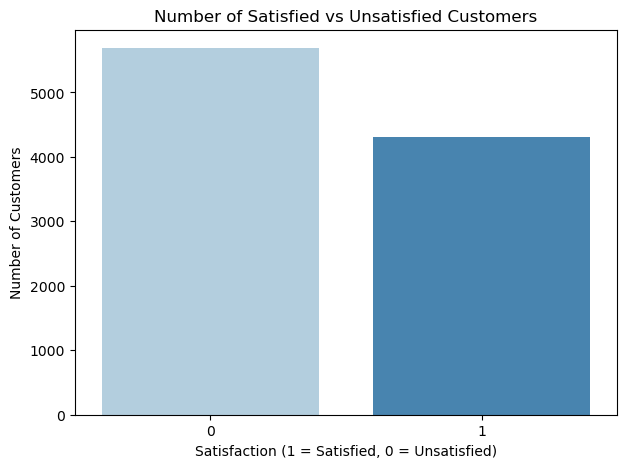

In [358]:
plt.figure(figsize=(7,5))
sns.barplot(x=satisfaction_counts.index,y=satisfaction_counts.values,palette='Blues')
plt.xlabel('Satisfaction (1 = Satisfied, 0 = Unsatisfied)')
plt.ylabel('Number of Customers')
plt.title('Number of Satisfied vs Unsatisfied Customers')
# plt.legend()
plt.show()


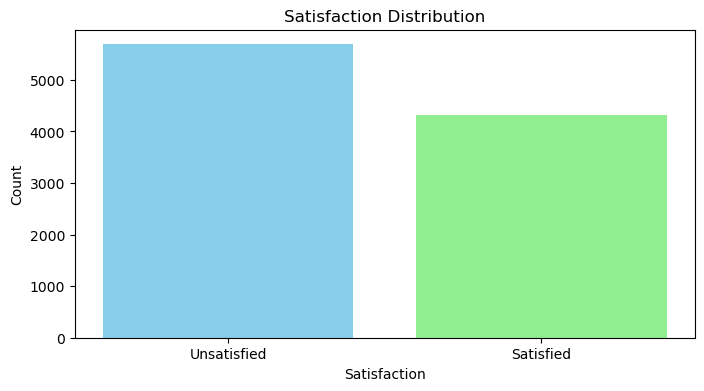

In [359]:
# both grap are same 

plt.figure(figsize=(8,4))

# Value counts (0 = unsatisfied, 1 = satisfied)
counts = new_data["satisfaction"].value_counts()

plt.bar(['Unsatisfied', 'Satisfied'], counts, color=['skyblue', 'lightgreen'])

plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.title('Satisfaction Distribution')

plt.show()


### 8) find the mean value of satisfaction of male and female customers

In [360]:
satisfaction_count=new_data.groupby('Gender')['satisfaction'].mean()*100

In [361]:
satisfaction_count

Gender
Female    42.443226
Male      43.806214
Name: satisfaction, dtype: float64

### 9) find the mean value of satisfaction of customers with respect to Age.

In [362]:
mean_customer_age=new_data.groupby("Customer_Type")['Age'].mean()*100

In [363]:
mean_customer_age

Customer_Type
Loyal Customer       4129.165143
disloyal Customer    3021.671309
Name: Age, dtype: float64

### 10) find the mean value of satisfaction of customers with respect to Food_and_drink.

In [364]:
food_satisfaction=new_data.groupby('Food_and_drink')['satisfaction'].mean()*100

In [365]:
food_satisfaction

Food_and_drink
0    62.500000
1    19.814241
2    36.230469
3    40.499040
4    51.505017
5    56.617647
Name: satisfaction, dtype: float64

### 11) Display a boxplot for Flight_Distance

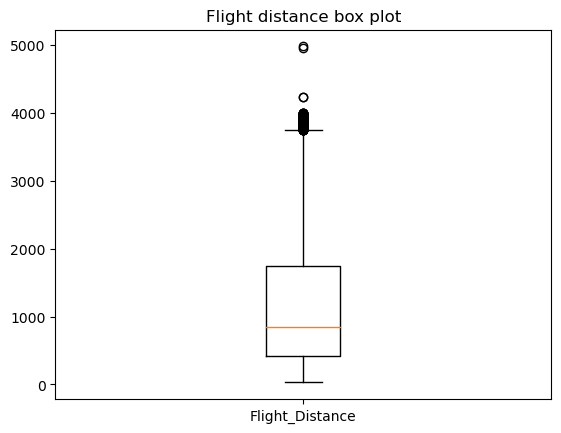

In [366]:
# Matplotlib → basic boxplot 
plt.title("Flight distance box plot")
plt.boxplot(new_data['Flight_Distance'],labels=['Flight_Distance'])
plt.show()

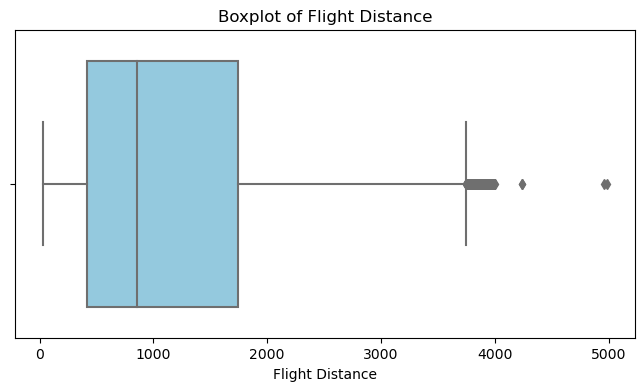

In [367]:
# both are same this is seaborn boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=new_data['Flight_Distance'], color='skyblue')
plt.title("Boxplot of Flight Distance")
plt.xlabel("Flight Distance")
plt.show()

### 12) Display a boxplot for Checkin_service 

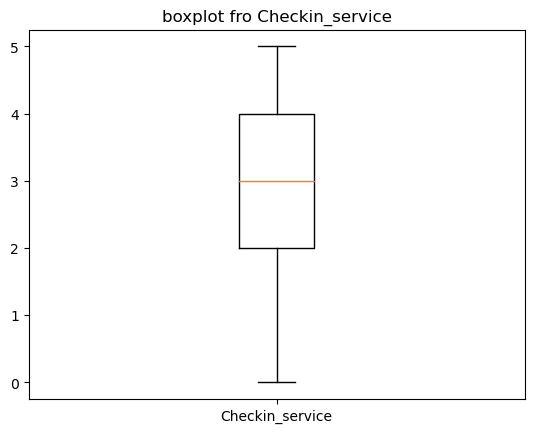

In [368]:
plt.title('boxplot fro Checkin_service')
plt.boxplot(new_data['Checkin_service'],labels=['Checkin_service'])
plt.show()

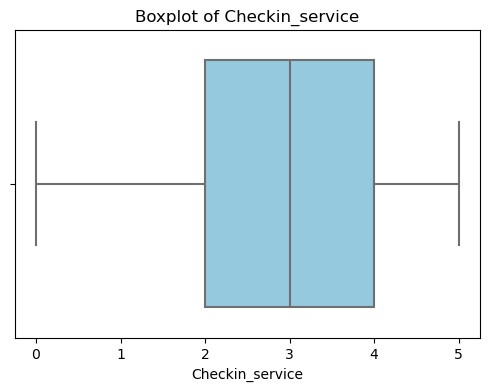

In [369]:
# both are same  and this is seaborn boxplot

plt.figure(figsize=(6,4))
sns.boxplot(x=new_data['Checkin_service'],color='skyblue')
plt.title("Boxplot of Checkin_service")
plt.xlabel("Checkin_service")
plt.show()

### 13) Find all the Null values 

In [370]:
new_data.isnull().sum()

Unnamed:_0.1                          0
id                                    0
Gender                                0
Customer_Type                         0
Age                                   0
Type_of_Travel                        0
Class                                 0
Flight_Distance                       0
Inflight_wifi_service                 0
Departure/Arrival_time_convenient     0
Ease_of_Online_booking                0
Gate_location                         0
Food_and_drink                        0
Online_boarding                       0
Seat_comfort                          0
Inflight_entertainment                0
On-board_service                      0
Leg_room_service                      0
Baggage_handling                      0
Checkin_service                       0
Inflight_service                      0
Cleanliness                           0
Departure_Delay_in_Minutes            0
Arrival_Delay_in_Minutes             26
satisfaction                          0


### 14) Drop all the na values 

In [371]:
new_data.dropna(inplace=True)

In [372]:
new_data.isnull().sum()

Unnamed:_0.1                         0
id                                   0
Gender                               0
Customer_Type                        0
Age                                  0
Type_of_Travel                       0
Class                                0
Flight_Distance                      0
Inflight_wifi_service                0
Departure/Arrival_time_convenient    0
Ease_of_Online_booking               0
Gate_location                        0
Food_and_drink                       0
Online_boarding                      0
Seat_comfort                         0
Inflight_entertainment               0
On-board_service                     0
Leg_room_service                     0
Baggage_handling                     0
Checkin_service                      0
Inflight_service                     0
Cleanliness                          0
Departure_Delay_in_Minutes           0
Arrival_Delay_in_Minutes             0
satisfaction                         0
dtype: int64

### 15) Find the unique values in Flight_Distance

In [373]:
flight_dis=new_data["Flight_Distance"].unique().tolist()

In [374]:
flight_dis

[460,
 235,
 1142,
 562,
 214,
 1180,
 1276,
 2035,
 853,
 1061,
 1182,
 308,
 834,
 946,
 453,
 486,
 2123,
 2075,
 2486,
 1174,
 208,
 752,
 2139,
 452,
 719,
 1561,
 315,
 3347,
 2342,
 819,
 1043,
 2611,
 1192,
 349,
 883,
 550,
 302,
 354,
 1734,
 1452,
 296,
 2882,
 529,
 1522,
 612,
 1454,
 731,
 2076,
 309,
 775,
 861,
 3334,
 2496,
 602,
 446,
 216,
 3475,
 646,
 2501,
 2227,
 1426,
 190,
 1532,
 157,
 1506,
 205,
 895,
 516,
 909,
 1435,
 1190,
 1259,
 1670,
 3960,
 817,
 406,
 404,
 500,
 689,
 3100,
 525,
 931,
 304,
 1896,
 261,
 347,
 1042,
 1773,
 342,
 297,
 332,
 2388,
 748,
 1080,
 231,
 551,
 972,
 265,
 488,
 1144,
 2332,
 3024,
 1750,
 483,
 2128,
 1852,
 372,
 3705,
 416,
 337,
 335,
 1400,
 2521,
 374,
 575,
 618,
 1304,
 351,
 549,
 3510,
 1620,
 326,
 588,
 1020,
 2903,
 2659,
 3037,
 2475,
 978,
 2568,
 371,
 791,
 480,
 1786,
 1849,
 3634,
 844,
 3094,
 3465,
 1035,
 237,
 3175,
 760,
 1071,
 728,
 2585,
 707,
 1790,
 680,
 888,
 1660,
 578,
 606,
 1487,
 317

## Part-2: Working with models 

### 1) Perform encoding in columns Gender, Customer_Type, Type_of_Travel, and Class.

In [375]:
new_data

,Unnamed:_0.1,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,0
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,0
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,0
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,124365,Male,Loyal Customer,50,Business travel,Business,3599,3,3,...,5,5,5,5,5,5,4,12,24.0,1
9996,9996,22044,Male,Loyal Customer,38,Business travel,Business,3873,5,5,...,4,4,4,4,3,4,5,0,0.0,1
9997,9997,14057,Female,Loyal Customer,39,Business travel,Business,319,4,4,...,4,4,4,4,3,4,2,0,0.0,1
9998,9998,113848,Male,Loyal Customer,52,Business travel,Business,1363,5,5,...,4,4,3,4,5,4,5,1,11.0,1


In [376]:
from sklearn.preprocessing import LabelEncoder

In [377]:
encode=LabelEncoder()

In [378]:
new_data['Gender']=encode.fit_transform(new_data['Gender'])

In [379]:
new_data['Customer_Type']=encode.fit_transform(new_data['Customer_Type'])

In [380]:
new_data['Type_of_Travel']=encode.fit_transform(new_data['Type_of_Travel'])

In [381]:
new_data['Class']=encode.fit_transform(new_data['Class'])

In [382]:
new_data

,Unnamed:_0.1,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,0,70172,1,0,13,1,2,460,3,4,...,5,4,3,4,4,5,5,25,18.0,0
1,1,5047,1,1,25,0,0,235,3,2,...,1,1,5,3,1,4,1,1,6.0,0
2,2,110028,0,0,26,0,0,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,3,24026,0,0,25,0,0,562,2,5,...,2,2,5,3,1,4,2,11,9.0,0
4,4,119299,1,0,61,0,0,214,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,124365,1,0,50,0,0,3599,3,3,...,5,5,5,5,5,5,4,12,24.0,1
9996,9996,22044,1,0,38,0,0,3873,5,5,...,4,4,4,4,3,4,5,0,0.0,1
9997,9997,14057,0,0,39,0,0,319,4,4,...,4,4,4,4,3,4,2,0,0.0,1
9998,9998,113848,1,0,52,0,0,1363,5,5,...,4,4,3,4,5,4,5,1,11.0,1


In [2]:
# Yes, it’s the same, but you can do it using only loops. When the model is a Decision Tree,
#Label Encoding is the best encoding method.”

# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()

# cols = ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']

# for c in cols:
#     New_Data[c] = le.fit_transform(New_Data[c])


### 2) Drop the column id and unnamed:_0.1

In [384]:
new_data.columns

Index(['Unnamed:_0.1', 'id', 'Gender', 'Customer_Type', 'Age',
       'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes',
       'satisfaction'],
      dtype='object')

In [385]:
new_data.drop(columns=['id','Unnamed:_0.1'],inplace=True)

### 3) Create the features and target Data 

In [386]:
x=new_data.drop(columns='satisfaction')

In [387]:
x.shape

(9974, 22)

In [388]:
y=new_data['satisfaction']

In [389]:
y.shape

(9974,)

### 4) Perform scaling on features data 

In [390]:
from sklearn.preprocessing import StandardScaler

In [391]:
scaler=StandardScaler()

In [392]:
x_scaler=scaler.fit_transform(x)

### 5) Split the data in training and testing sets 

In [393]:
from sklearn.model_selection import train_test_split

In [394]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=0)

In [395]:
x_train.shape

(7979, 22)

In [396]:
x_test.shape

(1995, 22)

### 6) Fit the decision tree model with various parameters 

In [397]:
from sklearn.tree import DecisionTreeClassifier

In [398]:
model=DecisionTreeClassifier()

In [399]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [400]:
y_pred=model.predict(x_test)

In [401]:
y_pred

array([0, 0, 1, ..., 1, 1, 0], dtype=int64)

In [402]:
accuracy_score(y_test,y_pred)

0.9233082706766917

In [ ]:
# both are same accuracy 

In [409]:
Train, Test = model.score(x_train, y_train) * 100, model.score(x_test, y_test) * 100
print("\nTraining Score = ", Train)
print("\nTesting Score = ", Test)


Training Score =  100.0

Testing Score =  92.33082706766918


### 6) Fit the decision tree model with various parameters 

### 7) Create a function to display precision score,recall score,accuracy,classification report,confusion matrix,F1 Score

In [438]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix

def show_metrics(Y_test, Y_pred):
    print("\nAccuracy Score       :", accuracy_score(Y_test, Y_pred))
    print("Precision Score      :", precision_score(Y_test, Y_pred, average='binary'))
    print("Recall Score         :", recall_score(Y_test, Y_pred, average='binary'))
    print("F1 Score             :", f1_score(Y_test, Y_pred, average='binary'))
    
    print("\nClassification Report:\n", classification_report(Y_test, Y_pred))
    print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))


In [439]:
y_pred = model.predict(x_test)
show_metrics(y_test, y_pred)



Accuracy Score       : 0.9233082706766917
Precision Score      : 0.9221556886227545
Recall Score         : 0.8974358974358975
F1 Score             : 0.9096278795038394

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      1137
           1       0.92      0.90      0.91       858

    accuracy                           0.92      1995
   macro avg       0.92      0.92      0.92      1995
weighted avg       0.92      0.92      0.92      1995

Confusion Matrix:
 [[1072   65]
 [  88  770]]
